# Individuell inlämningsuppgift – Deep Learning

In [39]:
# Grundläggande bibliotek
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Utvärdera klass balansering
from collections import Counter

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.metrics import classification_report

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing import image_dataset_from_directory


# Förtränad modell och rätt preprocessing för MobileNetV2
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 1. Dataförståelse

### 1.1. Ladda datan

In [2]:
# Load data
# specify directory to pull from
train_dir = "../data/train"
test_dir = "../data/test"

#define parameters
img_size = (48,48) # smaller pictures for faster performance.
batch_size = 32

# load data-sets
full_train_ds = image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int",
    shuffle=False,
    color_mode="grayscale" 
)

test_ds = image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="int",
    shuffle=False,
    color_mode="grayscale"
)

print("Train classes:", full_train_ds.class_names)
print("Test classes:", test_ds.class_names)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Train classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### 1.2. Antal bilder och klasser

In [3]:
#Visa antal bilder per sektion
def count_images(ds):
    total = 0
    for images, _ in ds:
        total += images.shape[0]
    return total

full_train_count = count_images(full_train_ds)
test_count = count_images(test_ds)


print("Bilder i train set:", full_train_count)
print("Bilder i test set:", test_count)
print("Bilder totalt:", full_train_count + test_count)

class_names = full_train_ds.class_names
print("Klasser:", class_names)

Bilder i train set: 28709
Bilder i test set: 7178
Bilder totalt: 35887
Klasser: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


- Datasetet innehåller 35,887 gråskaliga bilder där varje bild representeras i 48 x 48 pixels var.
- Datasetet är redan indelat i train-set: 28,709 bilder, och test-set: 7,178.
- Det finns 7 klasskategorier (labels). Varje label representerar vilken sorts ansiktsuttryck bilderna hamnar inom.

### 1.3. Klassfördelning

In [4]:
# Klassfördelning i train setet
counter = Counter()

for _, labels in full_train_ds:
    counter.update(labels.numpy().tolist())

class_distribution = pd.DataFrame.from_dict(counter, orient='index', columns=['count'])

class_distribution['class_name'] = class_distribution.index.map(lambda i: class_names[i])
class_distribution = class_distribution[['class_name', 'count']]

print(class_distribution)

  class_name  count
0      angry   3995
1    disgust    436
2       fear   4097
3      happy   7215
4    neutral   4965
5        sad   4830
6   surprise   3171


In [5]:
# Klassfördelning i test setet
test_counter = Counter()
for _, labels in test_ds:
    test_counter.update(labels.numpy().tolist())

test_distribution = pd.DataFrame.from_dict(test_counter, orient='index', columns=['count'])
test_distribution['class_name'] = test_distribution.index.map(lambda i: class_names[i])
test_distribution = test_distribution[['class_name', 'count']]
print(test_distribution)

  class_name  count
0      angry    958
1    disgust    111
2       fear   1024
3      happy   1774
4    neutral   1233
5        sad   1247
6   surprise    831


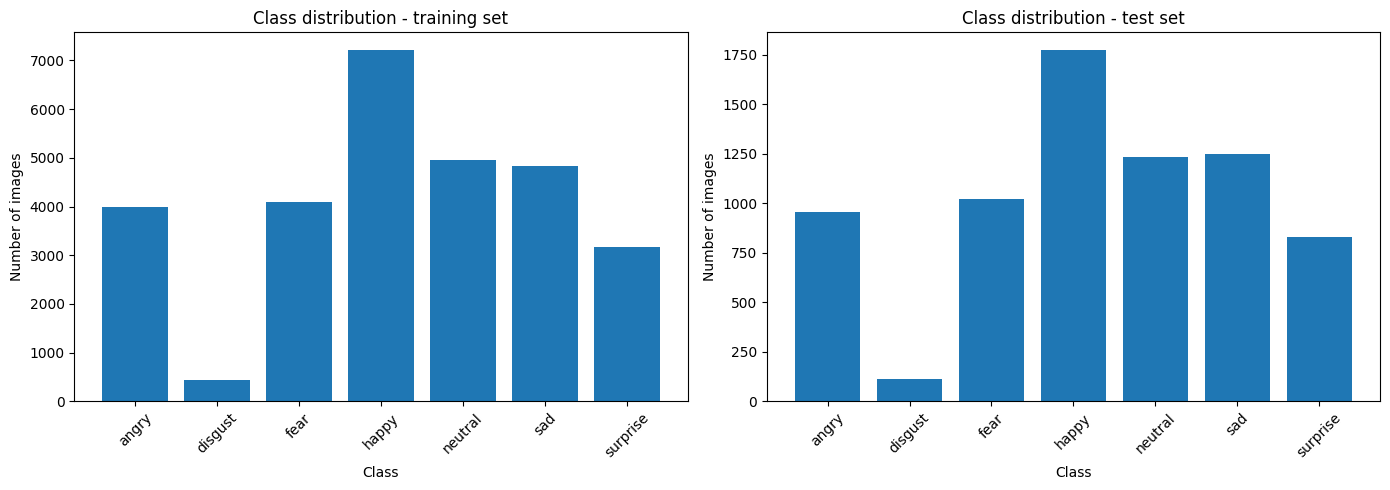

In [6]:
# Visualisering av klassfördelning i både train och test-set
counts = list(counter.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(class_names, counts)
axes[0].set_title("Class distribution - training set")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis='x', rotation=45)

test_counts = [test_counter[i] for i in range(len(class_names))]
axes[1].bar(class_names, test_counts)
axes[1].set_title("Class distribution - test set")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Number of images")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### 1.3.1. Disgust problemet

Klassfördelningen visar en tydlig obalans vilket syns tydligast i klassen *disgust* som enbart har 436 samples när resterande klasser ligger mellan 3,171 - 7,215 i train setet och liknande indelning i test-setet.

Det här begränsar antalet samples som kan användas för träning avsevärt vilket kan leda till större risk att modellen slutar lära sig av datan och istället memorerar den - därmed overfitting. 
Frågan om alla klasser bör användas kommer naturligt upp - om man skulle bortse från *disgust* - klassen skulle antalet tillgängliga samples gå upp från omkring 400 upp mot 3,000. 
Möjligheten att välja bort en klass bortsågs från det här projektet för att hålla datan så ärlig som möjligt, specillt eftersom test-setet speglar samma problematik. 


### 1.4. Pixelvärden

Figuren visar att bilder i träningssetet har pixelvärden inom intervallet 0 till 200, vilket gör dem stora och ojämna. Neurala nätverk tränar bättre på mindre och konsekventa inputvärden, därför kommer pixelvärdena att normaliseras innan den tränas på.

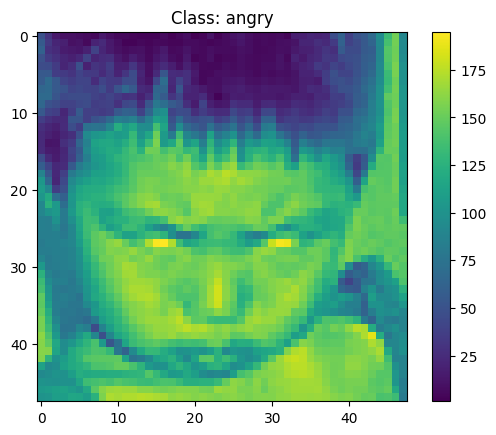

In [7]:

image_batch, label_batch = next(iter(full_train_ds))
image = image_batch[0].numpy().astype("uint8").squeeze()

plt.figure()
plt.imshow(image)
plt.colorbar()
plt.grid(False)
plt.title(f"Class: {full_train_ds.class_names[label_batch[0]]}")
plt.show()



### 1.5 Exempelbilder

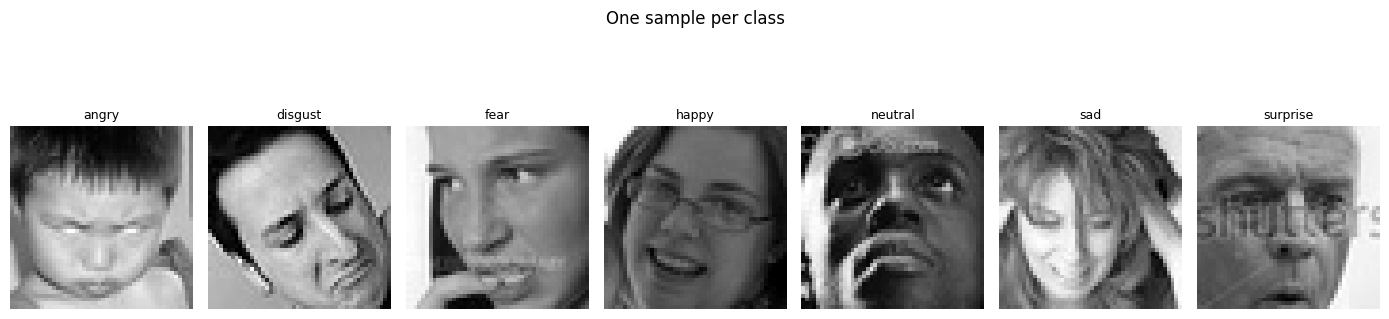

In [8]:
# En bild från varje folder (klass)

plt.figure(figsize=(14, 4))
shown = {}

for images, labels in full_train_ds:
    for img, label in zip(images, labels):
        label = label.numpy()
        if label not in shown:
            shown[label] = img.numpy().astype("uint8").squeeze()
        if len(shown) == 7:
            break
    if len(shown) == 7:
        break

for idx, (label_idx, img) in enumerate(sorted(shown.items())):
    plt.subplot(1, 7, idx + 1)
    plt.imshow(img, cmap='gray')
    plt.title(class_names[label_idx], fontsize=9)
    plt.axis('off')

plt.suptitle('One sample per class')
plt.tight_layout()
plt.show()

## 2. Dataförberedelser

### 2.1. Hantera klassobalansen

Som tidigare nämnts finns en tydlig obalans mellan dem 7 olika klasserna. I och med valet att ändå hålla kvar i alla klasserna i train-setet så måste obalansen hanteras, vilket görs på följande sätt:

1. Balanced subset sampling - när subset av train skapas väljs 400 samples från varje klass - på detta vis kan alla klasser tränas likadant även om det innebär att man i praktiken förbiser ~26,000 användbara bilder i träningsdatan.
2. Class_weights - Klassvikter hjälper modellen hantera minoritet klasser under träningen, men det löser ju inte hela problemet så är inte enda metoden som används för att hantera problematiken. Klassvikterna gav disgust vikter på omkring ~10-15x. 
3. Data augmentation - Data augmentering användes för att expandera subsetet genom att skapa modifierade versioner av datan.


### 2.1. Class weights

In [9]:
all_labels = np.concatenate([y.numpy() for _, y in full_train_ds], axis=0)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights))

print("\nClass weights:")
for idx, weight in class_weight_dict.items():
    print(f"  {class_names[idx]}: {weight:.4f}")


Class weights:
  angry: 1.0266
  disgust: 9.4066
  fear: 1.0010
  happy: 0.5684
  neutral: 0.8260
  sad: 0.8491
  surprise: 1.2934


### 2.2. Funktion för att skapa ett balanserat subset

Funktionen extraherar 400 samples från varje klass i train-setet till ett subset på 2,800 bilder, genom följande steg:
1. Extraherar alla indices från datasetet
2. Väljer balancerade etiketter per klass
3. Laddar enbart dem valda bilderna 
4. Blandar (shuffle) bilderna
5. Kollar att output är korrekt

In [10]:
def create_balanced_subset(ds, samples_per_class=400, random_state=42):
    """
    itererar genom datasetet två gånger - första passet samlar endast in etiketter,
    andra passet laddar endast de valda bilderna för att undvika att ladda hela datasetet i minnet
    """

    rng = np.random.default_rng(random_state)

    # Extraherar alla labels från datasetet
    all_labels = np.concatenate([labels.numpy() for _, labels in ds], axis=0)

    # Väljer balancerade indices per klass
    selected_indices = []
    for class_id in np.unique(all_labels):
        class_indices = np.where(all_labels == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )
        selected_indices.extend(chosen_indices)
    
    selected_indices = set(selected_indices)

    # Laddar enbart dem valda bilderna 
    selected_images = []
    selected_labels = []
    global_idx = 0

    for images, labels in ds:
        for i in range(len(images)):
            if global_idx in selected_indices:
                selected_images.append(images[i].numpy())
                selected_labels.append(labels[i].numpy())
            global_idx += 1

    selected_images = np.array(selected_images)  # shape: (2800, 48, 48, 1)
    selected_labels = np.array(selected_labels)  # shape: (2800,)

    # shuffle
    shuffle_idx = np.arange(len(selected_labels))
    rng.shuffle(shuffle_idx)

    print(f"Subset created: {len(selected_images)} images")
    print(f"Per class: {np.unique(selected_labels, return_counts=True)}")

    # kollar att output är korrekt
    assert len(selected_images) == len(np.unique(all_labels)) * samples_per_class, \
    f"Expected {len(np.unique(all_labels)) * samples_per_class} images, got {len(selected_images)}"

    return selected_images[shuffle_idx], selected_labels[shuffle_idx]

X_subset, y_subset = create_balanced_subset(full_train_ds, samples_per_class=400)




Subset created: 2800 images
Per class: (array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([400, 400, 400, 400, 400, 400, 400]))


### 2.3. Train/validation-split

- Träningsdatan delas upp i train (80%) och validation (20%)
- stratify=y_subset ser till att alla 7 klasser är propportioneligt representerade i båda seten.
- random_state=42 gör spliten reproducerbar.


In [11]:
# Dela upp train i train och validation
X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

print("X_train:", X_train.shape) 
print("X_val:", X_val.shape)

print("Train class distribution:", np.unique(y_train, return_counts=True))
print("Val class distribution:", np.unique(y_val, return_counts=True))

X_train: (2240, 48, 48, 1)
X_val: (560, 48, 48, 1)
Train class distribution: (array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([320, 320, 320, 320, 320, 320, 320]))
Val class distribution: (array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([80, 80, 80, 80, 80, 80, 80]))


### 2.4. Pipeline/ Normalisering

Två funktioner skapades - make_dataset och en liknande - make_dataset_transfer som skulle användas för transfer learning. Båda inkluderar följande steg: 

1. tf.data.Datset optimerar träningsdelen genom snabbare laddning, batching, parallel preprocessing, etc.
2. shuffle ser till att  bilderna dras slumpmässigt ur datan.
3. batch-size definerar hur många samples modellen går igenom åt gången.
4. Tillämpar en transformation på varje batch - på den första funktionen normaliseras datan genom /255 men i make_dataset_transfer ingår inte det - normalisering hanteras i preprocess_input
5. prefetch förbättrar pipeline processen genom att förbereda nästa batch som ska hanteras

In [12]:
def make_dataset(X, y, batch_size=32, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)  
    ds = ds.batch(batch_size)
    ds = ds.map(lambda X, y: (tf.cast(X, tf.float32) / 255.0, y))
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, shuffle=True)
val_ds   = make_dataset(X_val, y_val, shuffle=False)

test_ds = test_ds.map(lambda X, y: (tf.cast(X, tf.float32) / 255.0, y))\
                 .prefetch(tf.data.AUTOTUNE)


for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)
    print("dtype:", images.dtype)        
    print("min/max:", images.numpy().min(), images.numpy().max())




Image shape: (32, 48, 48, 1)
Label shape: (32,)
dtype: <dtype: 'float32'>
min/max: 0.0 1.0


In [13]:
def make_dataset_transfer(X, y, batch_size=32, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=42)
    ds = ds.batch(batch_size)
    ds = ds.map(lambda X, y: (tf.cast(X, tf.float32), y))  # no /255 - preprocess_input handles it
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_transfer = make_dataset_transfer(X_train, y_train, shuffle=True)
val_ds_transfer   = make_dataset_transfer(X_val, y_val)
test_ds_transfer  = test_ds.map(lambda X, y: (tf.cast(X, tf.float32), y))\
                            .prefetch(tf.data.AUTOTUNE)

### 2.4. Early stopping

För att undvika overfitting användes early_stopping som stoppar training när modellen slutar lära sig från datan.

In [14]:
def make_early_stopping(patience=5):
    return keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

## 3. Bygg en modell


### 3.1. Basmodel bygg och kompilering

Basmodellen byggdes baserad på följande arkitektur:
1. CNN-arkitektur med 3 convolutional lager (Conv2D) som används för att identifiera mönster i bilderna, följt av max pooling som minskar bilddimensionerna. 
2. Därefter används ett flatten-lager och dense-lager för klassificering. Lagret efter det använder Dropout för att slumpmässigt stänga av 30% av neuronerna under träning för regularisering.
3. Det slutliga output lagret konverterar den råa outputen (logits)  till sannolikheter för varje klass genom att använda Softmax.

(Augmentering - optimerad GPU användning som då kan reproduceras igenom på train/val/test delarna, samt håller tf.data-pipelinen ren. Detta valdes bort i basmodellen för att se hur det förbättrades i senare modeller.)

In [15]:
#Baseline CNN build funktion
def build_baseline_cnn():
    
    model = keras.Sequential([
        layers.Input(shape=(48,48, 1)),          

        # data augmentation - only active during training
        # layers.RandomFlip("horizontal"),            
        # layers.RandomRotation(0.1),                 
        # layers.RandomZoom(0.1),                     

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5), 
        
        layers.Dense(7, activation="softmax")       
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    
    return model
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,527 (2.61 MB)

 Trainable params: 683,527 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

### 3.2. Träning av basmodel

Baseline-modellen är byggd och har kompilerats så nästa steg är att tränas den på subsetet av train-datan. 
Validation datan används för att kunna följa hur modellen presterar på data som den inte tränats direkt på.

I den första baseline modellen användes 20 epochs och batch size 32. Resultatet sparas i history_baseline, vilket gör att vi senare kan visualisera utvecklingen av loss och accuracy under träningen.

In [16]:
start_time = time.time()

history_baseline = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    #class_weight=class_weight_dict,
    callbacks=[make_early_stopping(patience=5)] 
)


baseline_trainig_time = time.time() - start_time

print(f"Träningstid för baseline på subset: {baseline_trainig_time / 60:.2f} minuter")

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.1446 - loss: 1.9485 - val_accuracy: 0.1429 - val_loss: 1.9450
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.1531 - loss: 1.9430 - val_accuracy: 0.2000 - val_loss: 1.9363
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.1982 - loss: 1.9045 - val_accuracy: 0.2571 - val_loss: 1.8796
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.2500 - loss: 1.8479 - val_accuracy: 0.2929 - val_loss: 1.8180
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.2616 - loss: 1.8044 - val_accuracy: 0.3250 - val_loss: 1.7689
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3054 - loss: 1.7583 - val_accuracy: 0.3125 - val_loss: 1.7332
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3353 - loss: 1.6864 - val_accuracy: 0.3286 - val_loss: 1.7167
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3679 - loss: 1.6170 - val_accuracy: 0.3339 - v

### 3.3. Träningskurvor för loss och accuracy

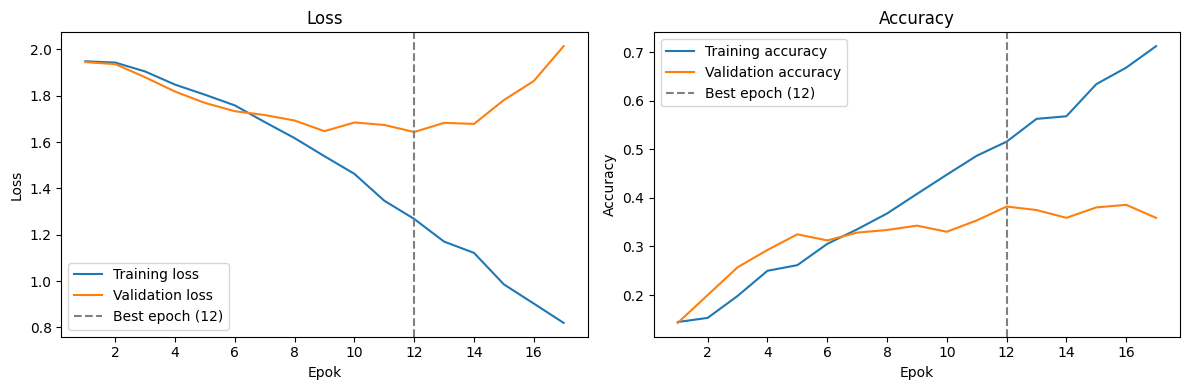

In [17]:
def plot_history(history):
    history_df = pd.DataFrame(history.history)
    epochs = range(1, len(history_df) + 1)
    best_epoch = history_df["val_loss"].idxmin() + 1

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation loss")
    plt.axvline(x=best_epoch, color='gray', linestyle='--', label=f"Best epoch ({best_epoch})")
    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history_df["accuracy"], label="Training accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation accuracy")
    plt.axvline(x=best_epoch, color='gray', linestyle='--', label=f"Best epoch ({best_epoch})")
    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline)



Båda kurvorna börjar tillsammans och visar att modellen lär sig effektivt fram till omkring epok 6. Där börjar modellen överanpassa sig då training loss fortsätter minska medan validation loss börja stiga tillbaka. Samma mönster syns i accuracy grafen där training accuracy når ~0.70 medan validation accuracy planar ut runt ~0.35.

Det växande gapet mellan training- och validation-kurvorna är det tydligaste tecknet på att modellen memorerar träningsdatan istället för att lära sig generaliserbara mönster. Detta beror troligtvis på att vi tränar på ett subset av datan som inte innehåller mycket variation.

### 3.4. Validation accuracy

In [18]:
baseline_history_df = pd.DataFrame(history_baseline.history)

best_epoch = baseline_history_df["val_loss"].idxmin() + 1
best_val_loss = baseline_history_df["val_loss"].min()
best_val_accuracy = baseline_history_df["val_accuracy"].iloc[best_epoch - 1]

print(f"Bästa validation loss vid epok: {best_epoch}")
print(f"Bästa validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy vid den epoken: {best_val_accuracy:.4f}")

Bästa validation loss vid epok: 12
Bästa validation loss: 1.6433
Validation accuracy vid den epoken: 0.3821


In [19]:
# Extrahera x & y värden från datasetet
def extract_xy(dataset):
    X_list = []
    y_list = []
    for images, labels in dataset:
        X_list.append(images.numpy())
        y_list.append(labels.numpy())
    return np.concatenate(X_list), np.concatenate(y_list)

X_val_extracted, y_val_extracted = extract_xy(val_ds)

# Predict på extraherade värden
y_proba = baseline_model.predict(X_val_extracted)
y_pred = np.argmax(y_proba, axis=1)

#Räkna ut accuracy
val_accuracy = accuracy_score(y_val_extracted, y_pred)
print(f"Validation accuracy: {val_accuracy:.4f}")
print(classification_report(y_val_extracted, y_pred, target_names=class_names))


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Validation accuracy: 0.3821
              precision    recall  f1-score   support

       angry       0.37      0.35      0.36        80
     disgust       0.58      0.70      0.63        80
        fear       0.20      0.24      0.22        80
       happy       0.41      0.40      0.40        80
     neutral       0.24      0.16      0.19        80
         sad       0.24      0.26      0.25        80
    surprise       0.65      0.56      0.60        80

    accuracy                           0.38       560
   macro avg       0.38      0.38      0.38       560
weighted avg       0.38      0.38      0.38       560



### 3.5. Confusion Matrix

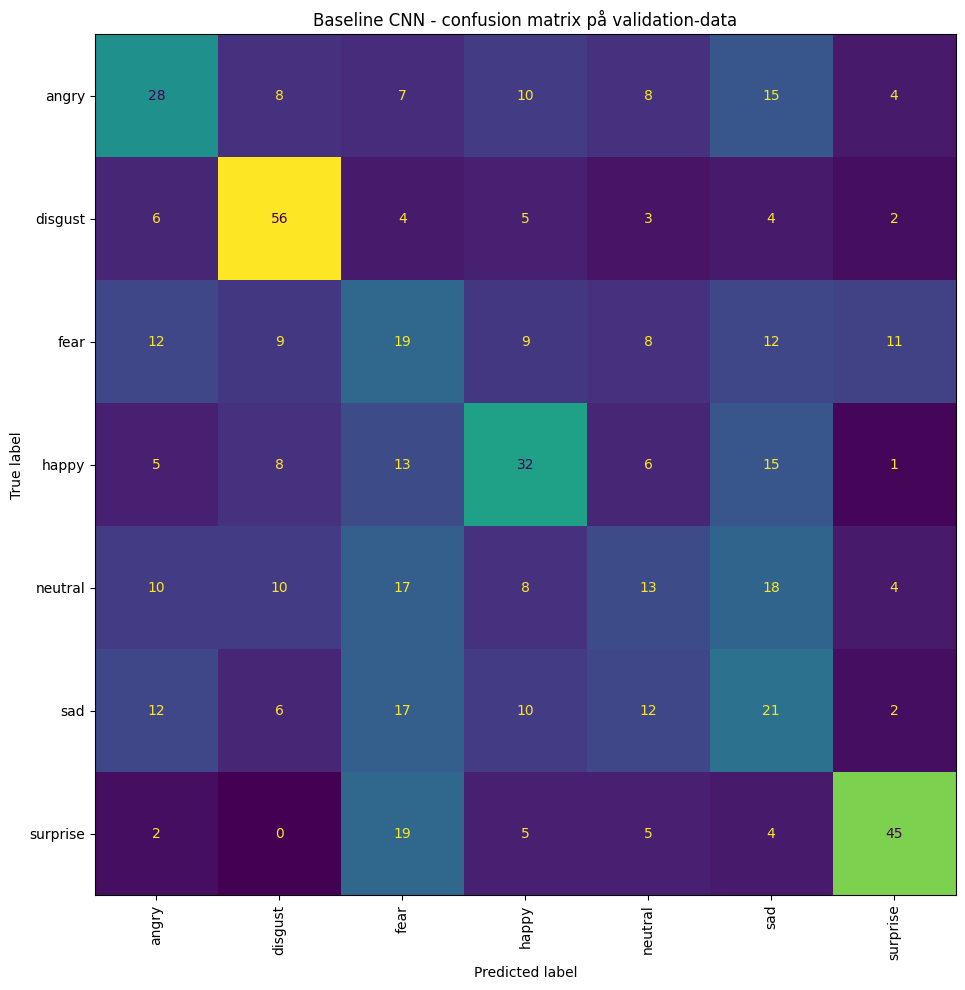

In [20]:
#Skapa confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(12, 10))

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )
    display.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

    return cm

baseline_cm = plot_confusion_matrix(
    y_val_extracted, 
    y_pred,
    class_names,
    title="Baseline CNN - confusion matrix på validation-data"
)

Confusion matrixen visar väldigt intressant trender: 

Bäst presterande klasser
- Disgust (56) — överraskande med tanke på restriktionerna med den här klassen 
- Surprise (45) — en av dem mest distinkta ansiktsuttrycken
- Happy (32) — visuellt lätt att känna igen (leende)

Sämst presterande klasser
- Neutral (13) — förväxlad med ledsen (12 gånger)
- Fear (19) — fördelat över alla klasser
- Sad (21) - fördelat över alla klasser

Confusion matrixen  visar att modellen lär sig visuellt distinkta uttryck som avsky, förvåning och glädje, men kämpar med mer lågintensiva ansiktsuttryck (neutral och ledsen). Detta verkar överensstämma ganska bra med mänsklig ansiktsuttrycksigenkänning.  

### 3.6. Accuracy per klass

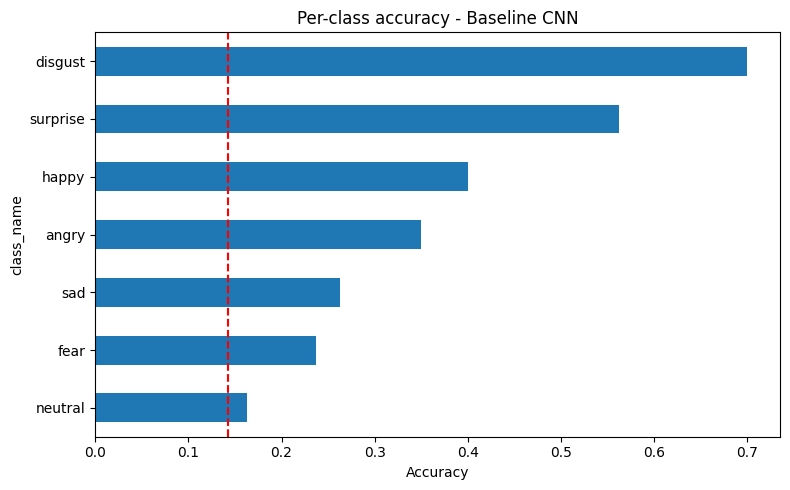

In [21]:
def calculate_per_class_accuracy(cm, class_names):

    support = cm.sum(axis=1)
    correct = np.diag(cm)

    accuracy = np.divide(
        correct,
        support,
        out=np.zeros_like(correct, dtype=float),
        where=support != 0
    )

    result = pd.DataFrame({
        "class_id": np.arange(len(class_names)),
        "class_name": class_names,
        "support": support,
        "correct": correct,
        "accuracy": accuracy
    })

    return result.sort_values("accuracy")


baseline_per_class = calculate_per_class_accuracy(
    baseline_cm,
    class_names
)

baseline_per_class.plot(
    kind='barh',
    x='class_name',
    y='accuracy',
    legend=False,
    figsize=(8, 5)
)
plt.axvline(x=1/7, color='red', linestyle='--', label='Random baseline (14.3%)')
plt.title('Per-class accuracy - Baseline CNN')
plt.xlabel('Accuracy')
plt.tight_layout()
plt.show()

### 3.7. Vanligast förväxlingarna

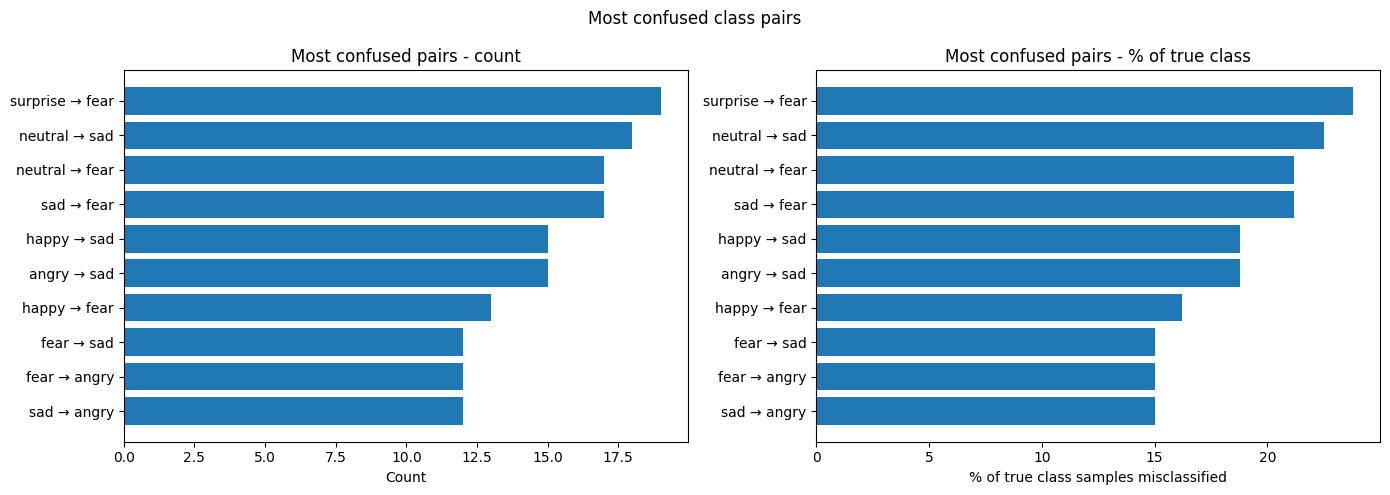

,true_class,predicted_class,count,pct_of_true_class
37,surprise,fear,19,23.8
28,neutral,sad,18,22.5
26,neutral,fear,17,21.2
32,sad,fear,17,21.2
22,happy,sad,15,18.8
4,angry,sad,15,18.8
20,happy,fear,13,16.2
16,fear,sad,12,15.0
12,fear,angry,12,15.0
30,sad,angry,12,15.0


In [22]:
def get_most_confused_pairs(cm, class_names, top_n=10):
    pairs = []
    support = cm.sum(axis=1)

    for true_class in range(cm.shape[0]):
        for predicted_class in range(cm.shape[1]):
            if true_class == predicted_class:
                continue

            count = cm[true_class, predicted_class]

            if count > 0:
                pairs.append({
                    "true_class": class_names[true_class],
                    "predicted_class": class_names[predicted_class],
                    "count": count,
                    "pct_of_true_class": round(count / support[true_class] * 100, 1)
                })

    pairs_df = pd.DataFrame(pairs)

    if pairs_df.empty:
        return pairs_df

    pairs_df = pairs_df.sort_values("count", ascending=False).head(top_n)

    # visualization
    pairs_df["pair"] = pairs_df["true_class"] + " → " + pairs_df["predicted_class"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # count plot
    axes[0].barh(pairs_df["pair"], pairs_df["count"])
    axes[0].invert_yaxis()
    axes[0].set_title("Most confused pairs - count")
    axes[0].set_xlabel("Count")

    # percentage plot
    axes[1].barh(pairs_df["pair"], pairs_df["pct_of_true_class"])
    axes[1].invert_yaxis()
    axes[1].set_title("Most confused pairs - % of true class")
    axes[1].set_xlabel("% of true class samples misclassified")

    plt.suptitle("Most confused class pairs")
    plt.tight_layout()
    plt.show()

    return pairs_df.drop(columns="pair")


baseline_confusions = get_most_confused_pairs(
    baseline_cm,
    class_names
)

baseline_confusions

Viktiga förvirringsmönster

- Surprise → Fear (18 gånger) - är intuitivt logiskt då båda kan innehålla del av överraskningsuttryck
- Neutral → Sad (17.5 gånger) — modellen kämpar med att urskilja lågintensiva uttryck
- Rädsla förväxlas med nästan allt — den svåraste klassen att lära sig

## 4. Bygg en förbättrad modell

Vi har nu en fungerande baseline-modell med en val_accuracy på ~38 %.

Nästa steg är att systematiskt förbättra den. Med tanke på overfitting som vi såg i baseline-modellen så har följande delar stegvis lagts till i den förbättrade modellen:

1. Augmentering - optimerad GPU användning som då kan reproduceras igenom på train/val/test delarna, samt håller tf.data-pipelinen ren.
2. BatchNormalization — stabiliserar träning mellanlagren
3. Ökade dropout från 0.5 till 0.6
4. Early stopping las till så att modellen slutar träna innan överfitting påbörjas.
5. Ändrade learning rate från 0.001 till 0.0001

Testades men togs bort från modellen:

6. Försökte använda compute_class_weight("balanced") från sklearn, vilket gav *disgust* en vikt på ~10-15x. Det orsakade modellkollaps — modellen lärde sig att förutsäga *disgust*  för varje bild eftersom det minimerade den viktade förlusten. Mjukare anpassade vikter (custom_weights) testades också med samma resultat.

### 4.1. Förbättrad modell

In [23]:
def build_improved_model():
    
    model = keras.Sequential([
        layers.Input(shape=(48,48, 1)),

        # data augmentation
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.6),                        # increased from 0.5 to 0.6 to reduce overfitting
        layers.Dense(7, activation="softmax")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001), # 👈 changed learning rate from 0.001 to 0.0001
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    
    return model

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

improved_model = build_improved_model()

improved_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,423 (2.61 MB)

 Trainable params: 683,975 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

### 4.2. Resultat

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 67ms/step - accuracy: 0.1670 - loss: 2.4791 - val_accuracy: 0.1536 - val_loss: 2.1712
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 65ms/step - accuracy: 0.1661 - loss: 1.9606 - val_accuracy: 0.1446 - val_loss: 2.4865
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.1768 - loss: 1.9526 - val_accuracy: 0.1554 - val_loss: 2.5372
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.1612 - loss: 1.9416 - val_accuracy: 0.1446 - val_loss: 2.4499
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.1710 - loss: 1.9370 - val_accuracy: 0.1696 - val_loss: 2.2478
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.1911 - loss: 1.9288 - val_accuracy: 0.1929 - val_loss: 2.0871
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.1902 - loss: 1.9267 - val_accuracy: 0.2071 - val_loss: 1.9824
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 64ms/step - accuracy: 0.1911 - loss: 1.9256 - val_accuracy: 0.2196 - v

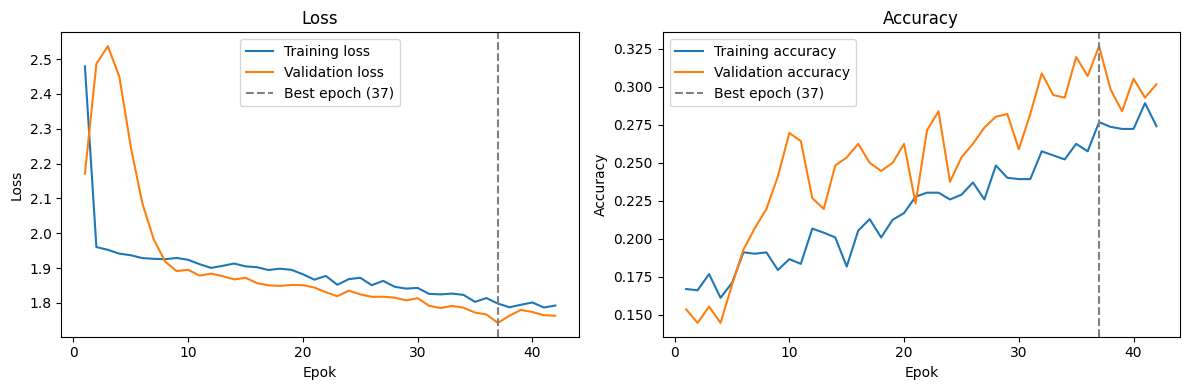

In [24]:
start_time = time.time()

custom_weights = {
    0: 1.5,  # angry
    1: 3.0,  # disgust
    2: 1.5,  # fear
    3: 1.0,  # happy
    4: 1.2,  # neutral
    5: 1.3,  # sad
    6: 1.5,  # surprise
}

improved_model_history = improved_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    #class_weight=custom_weights,
    callbacks=[make_early_stopping(patience=5)]
)

subset_training_time = time.time() - start_time

print(f"Träningstid för förbättrad modell på subset: {subset_training_time / 60:.2f} minuter")

plot_history(improved_model_history)

In [25]:
improved_model_history_df = pd.DataFrame(improved_model_history.history)

best_epoch = improved_model_history_df["val_loss"].idxmin() + 1
best_val_loss = improved_model_history_df["val_loss"].min()
best_val_accuracy = improved_model_history_df["val_accuracy"].iloc[best_epoch - 1]

print(f"Bästa validation loss vid epok: {best_epoch}")
print(f"Bästa validation loss: {best_val_loss:.4f}")
print(f"Validation accuracy vid den epoken: {best_val_accuracy:.4f}")

Bästa validation loss vid epok: 37
Bästa validation loss: 1.7428
Validation accuracy vid den epoken: 0.3268


Den förbättrade modellen visar att dem medel som använts för att undvika överanpassning verkar fungera - träning och följs genomgående och validering överträffar faktiskt träningen något i både loss och accuracy. Detta är den förväntade augmenteringseffekten – augmentering gör träningen svårare så validering ser jämförelsevis bättre ut.

Early stopping utlöstes vid epok 42 och återställde bästa vikter från epok 37, så modellen fick den träningstid den behövde. 

Modellen ligger lägre i accuracy - 32.7% - än baselinemodellen (~38%) vilket kan ha att göra med att class_weights togs bort och modellen har svårare att träna på obalanserade klasser. Tyvärr funkade class_weights inte i samband med dem andra ändringar som las till och ledde kontinuerligt till modellkollaps även när en mjukare version användes, så togs till sist bort från modellen. 

Valideringskurvan verkar väldigt ojämn vilket kan vara på grund av att valideringssetet (560 bilder) är mindre än train setet (2240).   

## 5. Transfer modell

Den första basmodellen som byggdes nådde en accuracy på ~38% vilket inte förbättrades genom nästa förbättrade modell. Med tanke på data storleken och dess gränser känns det osannolikt att vi kommer att kunna förbättra resultatet mycket mer genom att försöka förbättra basmodellen. Istället går vi vidare till Transfer learning och använder MobileNetV2 som passar bild klassificering  eftersom den har förtränade vikter som fungerar även på ett mindre dataset.

För att skapa en transfer modell så skapades först separata dataset enbart för transfer modellen via make_dataset_transfer funktionen.

### 5.1. Transfer modell bygg och kompilering

Transfer modellen som byggdes baserad på MobileNetV2 inkluderade följande steg:

1. Augmentering - optimerad GPU användning som då kan reproduceras igenom på train/val/test delarna, samt håller tf.data-pipelinen ren. Detta valdes bort i basmodellen för att se hur det förbättrades i senare modeller
2. Uppsampling från 48x48 till 96x96 inuti modellen så att det passar minimi-storleken för MobileNetV2
3. Konvertering från gråskala till 3 kanaler 
3. Applicering av mobilenet preprocessing
4. Applicering av MobileNetV2 basmodel , följt av GlobalAveragePooling2D istället för ett flatten-lager och ett dense-lager för klassificering.
5. Lagret efter det använder Dropout för att slumpmässigt stänga av 50% av neuronerna under träning för regularisering.
6. Det slutliga output lagret konverterar den råa outputen (logits)  till sannolikheter för varje klass genom att använda Softmax.




In [26]:
def build_transfer_model():
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(42)

    base_model = keras.applications.MobileNetV2(
        input_shape=(96, 96, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(48, 48, 1))

    # augmentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.1)(x)
    x = layers.RandomZoom(0.1)(x)

    # uppsampling från 48x48 till 96x96 inuti modellen
    x = layers.Resizing(96, 96)(x)

    # convert grayscale to 3 channels
    x = layers.Conv2D(3, (1, 1), padding="same")(x)

    # apply mobilenet preprocessing - expects [0, 255]
    x = keras.applications.mobilenet_v2.preprocess_input(x)

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(7, activation="softmax")(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.0001),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

### 5.2. Transfer modell träning och resultat

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 18s 209ms/step - accuracy: 0.1522 - loss: 2.3999 - val_accuracy: 0.1768 - val_loss: 1.9812
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 195ms/step - accuracy: 0.1844 - loss: 2.0311 - val_accuracy: 0.2304 - val_loss: 1.9189
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 197ms/step - accuracy: 0.1875 - loss: 1.9526 - val_accuracy: 0.2446 - val_loss: 1.9028
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 190ms/step - accuracy: 0.2156 - loss: 1.9203 - val_accuracy: 0.2500 - val_loss: 1.8865
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - accuracy: 0.2147 - loss: 1.9013 - val_accuracy: 0.2696 - val_loss: 1.8711
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - accuracy: 0.2241 - loss: 1.8909 - val_accuracy: 0.2625 - val_loss: 1.8606
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 13s 189ms/step - accuracy: 0.2415 - loss: 1.8836 - val_accuracy: 0.2839 - val_loss: 1.8430
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 14s 194ms/step - accuracy: 0.2335 - loss: 1.8776 - val_accu

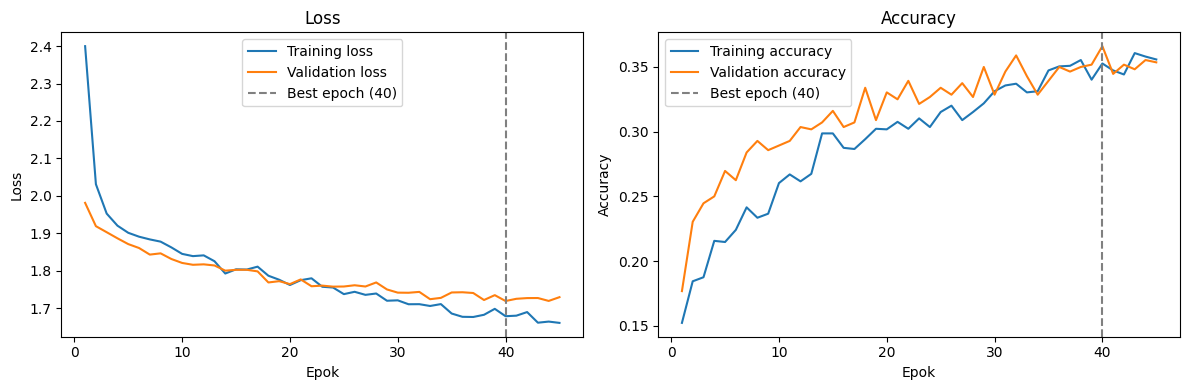

In [27]:
transfer_model = build_transfer_model()


start_time = time.time()

transfer_history = transfer_model.fit(
    train_ds_transfer,      # ingen /255 normalisering - görs via mobilenet preprocessing 
    validation_data = val_ds_transfer,
    epochs=50,
    # inga class weights
    callbacks=[make_early_stopping(patience=5)]
)

subset_training_time = time.time() - start_time
print(f"Träningstid för transfer model på subset: {subset_training_time / 60:.2f} minuter")

plot_history(transfer_history)

|                  | Training    | Validation|
|:--------         |:--------    |:--------  |
| Final accuracy   |  ~35%       |  ~35%     |
| Best epoch       | 40          |  40       |
| Loss range       | 1.67-2.4    | 1.72-2.0  |


Båda kurvorna följer när varandra, så ingen överanpassning. Transfer modellen verkar fungera som en bra regulariserare vilket syns på den stadiga förbättringen över 40 epoker.
Loss började lågt (~2.0) och minskade smidigt, ingen synbar instabilitet. I accuracy grafen är validering lite mer instabil men fortfarande inga tydliga spår av överanpassning.

De mest överraskande med accuracy grafen är att högsta accuracy värdet ligger på ~35% vilket är lägre än basmodellen (~38%). De frysta MobileNetV2-vikterna överförs inte så effektivt som hoppats, troligen för att ImageNet-funktioner inte mappas perfekt till gråskaliga 48×48 ansiktsuttryck även efter storleksändring.

### 5.2. Finjustering av transfer modell

För att finjustera denna transfer modell börjar vi med att låsa upp de översta lagren och fortsätta träna modellen - nu med en lägre träningstakt (0.000001).


Trainable layers in base model: 30
Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.1835 - loss: 2.6339 - val_accuracy: 0.3589 - val_loss: 1.7249
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 212ms/step - accuracy: 0.1813 - loss: 2.5758 - val_accuracy: 0.3464 - val_loss: 1.7322
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accuracy: 0.1835 - loss: 2.5560 - val_accuracy: 0.3429 - val_loss: 1.7408
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 218ms/step - accuracy: 0.1897 - loss: 2.5270 - val_accuracy: 0.3357 - val_loss: 1.7489
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step - accuracy: 0.1795 - loss: 2.5160 - val_accuracy: 0.3411 - val_loss: 1.7563
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 15s 211ms/step - accuracy: 0.1942 - loss: 2.4864 - val_accuracy: 0.3357 - val_loss: 1.7652


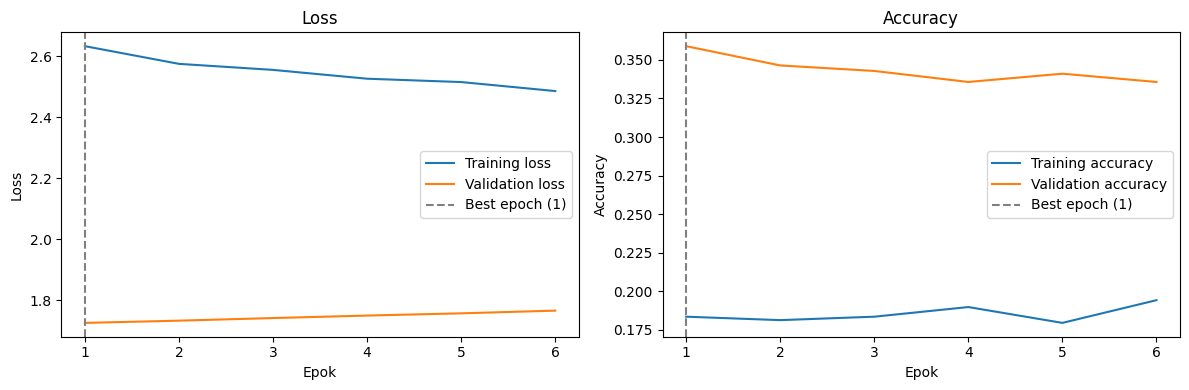

In [28]:
# Lås upp top 30 lager av basmodellen
base_model = transfer_model.layers[6]
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers in base model: {sum([l.trainable for l in base_model.layers])}")

# recompilering med lägre learning rate
transfer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.000001),# 10x lägre learning rate 0.000001
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# finjustering
phase2_history = transfer_model.fit(
    train_ds_transfer,
    validation_data=val_ds_transfer,
    epochs=20,
    callbacks=[make_early_stopping(patience=5)]
)

plot_history(phase2_history)



Graferna visar resultatet efter att jag dragit ner learning rate två gånger - sist nu till 0.000001.
Finjusteringen har inte förbättrat resultatet alls - valideringsaccuracyn ligger ännu lägre än innan finjusteringen på ~33 % medan träningsaccuracyn ligger ännu lägre på ~21 %. Detta är en tydlig signal om att finjustering snarare skadar än hjälper.

Inlärningshastigheten kan fortfarande vara för hög för finjustering – även vid 0,00001 uppdateras de ofrysta lagren för aggressivt och skriver över de förtränade vikterna som redan fungerade bra från den första transfer modellen. Den versionen har redan hittat den optimala punkten – den frysta basen nådde ~35 % och finjustering har inget mer att erbjuda med tanke på den lilla datamängd som finns.

### 5.3. Utvärdering av transfer modell

18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step
Transfer model validation accuracy: 0.3589
              precision    recall  f1-score   support

       angry       0.33      0.28      0.30        80
     disgust       0.40      0.20      0.27        80
        fear       0.29      0.20      0.24        80
       happy       0.40      0.49      0.44        80
     neutral       0.26      0.30      0.28        80
         sad       0.31      0.28      0.29        80
    surprise       0.45      0.78      0.57        80

    accuracy                           0.36       560
   macro avg       0.35      0.36      0.34       560
weighted avg       0.35      0.36      0.34       560



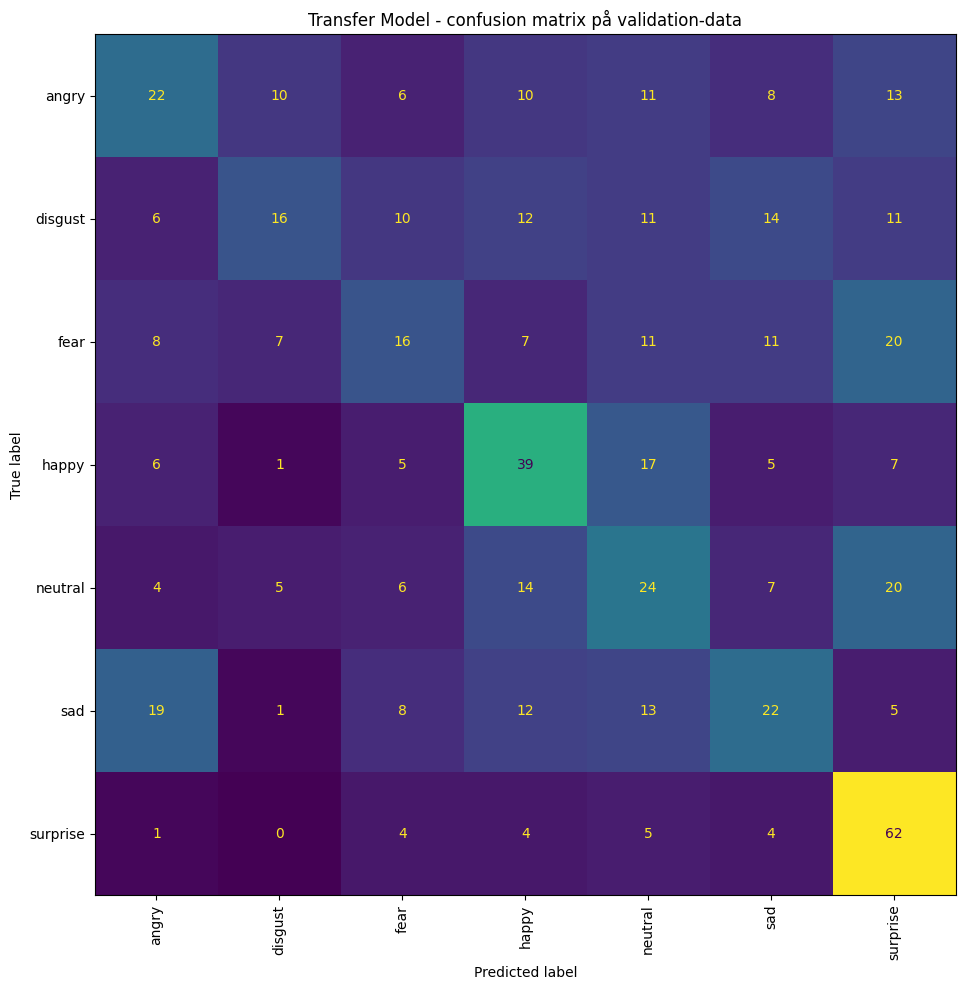

   class_id class_name  support  correct  accuracy
1         1    disgust       80       16    0.2000
2         2       fear       80       16    0.2000
0         0      angry       80       22    0.2750
5         5        sad       80       22    0.2750
4         4    neutral       80       24    0.3000
3         3      happy       80       39    0.4875
6         6   surprise       80       62    0.7750


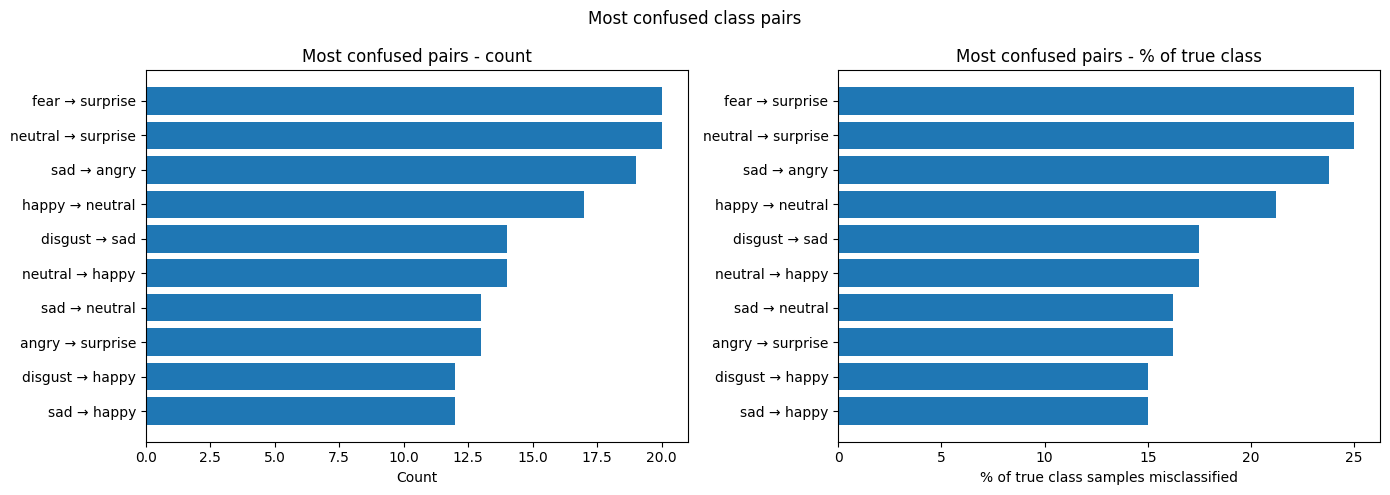

In [29]:
# extract predictions
X_val_transfer, y_val_transfer = extract_xy(val_ds_transfer)
y_proba_transfer = transfer_model.predict(X_val_transfer)
y_pred_transfer = np.argmax(y_proba_transfer, axis=1)

# accuracy
val_accuracy = accuracy_score(y_val_transfer, y_pred_transfer)
print(f"Transfer model validation accuracy: {val_accuracy:.4f}")

# classification report
print(classification_report(y_val_transfer, y_pred_transfer, target_names=class_names))

# confusion matrix
transfer_cm = plot_confusion_matrix(
    y_val_transfer,
    y_pred_transfer,
    class_names,
    title="Transfer Model - confusion matrix på validation-data"
)

# per class accuracy
transfer_per_class = calculate_per_class_accuracy(transfer_cm, class_names)
print(transfer_per_class)

# confused pairs
transfer_confusions = get_most_confused_pairs(transfer_cm, class_names)

Här är trenderna i transfer modellen:

34.5% validation accuracy — i linje med träningsgraferna

Starka klasser:

- Surprise (63)  — överlägset bäst. Överraskning har mycket distinkta drag (höjda ögonbryn, öppen mun)
- Happy (40) — leende är visuellt distinkt

Svaga klasser:

- Fear (7) — modellen identifierar nästan aldrig rädsla korrekt
- Disgust (16) — dåligt inlärd trots att den tillhör minoritetsklassen
- Neutral (17) — subtilt uttryck, svårt att skilja


Intressanta resultat från diagrammet över förvirrade par
- Rädsla → Överraskning (23 gånger, ~29 %) — den största förvirringen. Båda involverar vidöppna ögon och öppen mun, vilket gör dem visuellt lika vid 48×48 upplösning.
- Neutral → Överraskning (22 gånger, ~28 %) — överraskande men förklarligt. Vid låg upplösning kan neutrala ansikten visa något öppna munnar som modellen misstolkar som överraskning.
- Ledsen → Arg (22 gånger, ~28%) — båda negativa uttryck med liknande muskelmönster runt ögon och mun.

Jämförelse mellan topp 2 modeller

|                  |Val accuracy | Best class    | Worst class|
|:--------         |:--------    |:--------      |:--------   |
| Basmodell        |  ~38%       |Surprise (56%) |Neutral(15%)|
| Transfermodell   |  ~35%       |Surprise (79%) |Fear (9%)   |


När man jämför baslinje vs transfer så har transfer modellen ett mycket högre tak för enkla klasser (överraskning 79% vs baslinje 56%) men presterar sämre på svåra klasser. Detta kan tyda på att den lärde sig mer specialiserade funktioner men blev övermodig i överraskning på bekostnad av andra klasser. 

Basmodellen presterade bättre än transfer modellen, vilket är kontraintuitivt men kan kanske förklaras på grund av att datasetet var på gråskalebilder i 48×48-upplösning och endast 2 240 träningsexempel. Dessa är alla villkor som motverkar ImageNet-överföringsinlärning, som designades för fullfärgsbilder med mycket högre upplösning så kan ha lett till det lägre accuracy värdena. 

## 6. Utvärdering av den bästa modellen

Baslinjemodellen CNN är tekniskt sett den bästa modellen med ~39 % accuracy, men för denna rapport valdes transfer learning modellen för att testa först full train setet och sedan förhoppningsvis test-setet. 
Anledningen till valet är:

- Transfer modellen visar det högsta taket per klass (överraskning vid 79 %)
- Den demonstrerar mer sofistikerad metodologi
- Inlärningskurvan är den mest stabila av modellerna.

### 6.1. Träning på fullt training set

Epoch 1/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 160s 173ms/step - accuracy: 0.8553 - loss: 0.7983 - val_accuracy: 0.1429 - val_loss: 7.3836
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 156s 174ms/step - accuracy: 0.6272 - loss: 1.5026 - val_accuracy: 0.1429 - val_loss: 3.8812
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 155s 172ms/step - accuracy: 0.5571 - loss: 1.5549 - val_accuracy: 0.1429 - val_loss: 4.7409
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 157s 174ms/step - accuracy: 0.4950 - loss: 1.8233 - val_accuracy: 0.1429 - val_loss: 4.9841
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 155s 173ms/step - accuracy: 0.5147 - loss: 1.6568 - val_accuracy: 0.1429 - val_loss: 4.1251
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 159s 177ms/step - accuracy: 0.6034 - loss: 1.4474 - val_accuracy: 0.1411 - val_loss: 5.9542
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 154s 172ms/step - accuracy: 0.5368 - loss: 1.5532 - val_accuracy: 0.1571 - val_loss: 3.2854
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 156s 174ms/step - accuracy: 0.5855 -

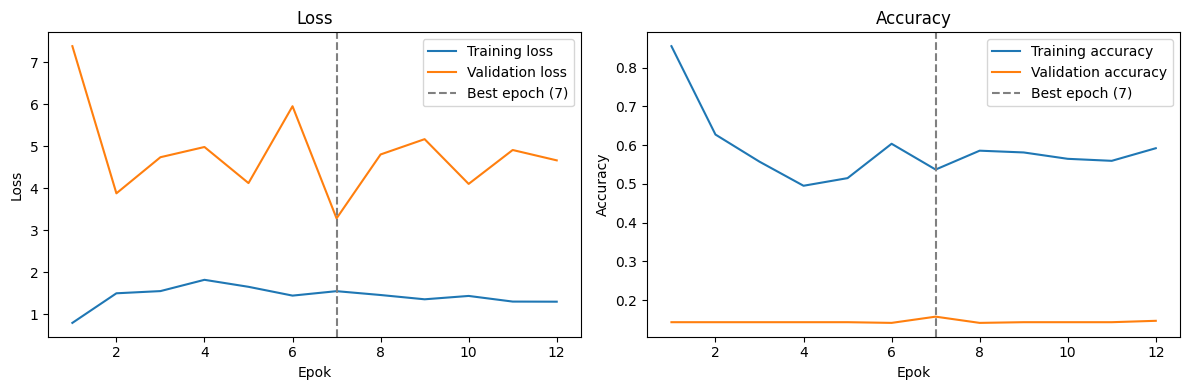

In [36]:
# 1. Förbereda full_train för transfer modellen (no /255)
full_train_ds_transfer = full_train_ds.map(lambda X, y: (tf.cast(X, tf.float32), y))\
                                      .prefetch(tf.data.AUTOTUNE)

# 2. Refresh model build
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

transfer_model_full = build_transfer_model()

# 3. Träna på hela train setet
start_time = time.time()

transfer_full_history = transfer_model_full.fit(
    full_train_ds_transfer,
    validation_data=val_ds_transfer,   
    epochs=50,
    callbacks=[make_early_stopping(patience=5)]
)

training_time = time.time() - start_time
print(f"Training time: {training_time / 60:.2f} minutes")

plot_history(transfer_full_history)

Dessa resultat visar ett allvarligt problem – training accuracy ~55 % men validation accuracy har fastnat på ~17 %. 
Detta är extrem överanpassning och det värsta train/val-gapet hittills. 

Problemet är tydligen på valideringsdatan vilket låter konstigt tills vi jämför datamängden - valideringsdatan är fortfarande samma mängd som innan - 560 bilder medan vi nu jämför mot hela träningsdatan vilket är 28,000 bilder. Dessa två fördelningar är ojämna, vilket gör valideringsmåtten meningslösa.
Loss skalan är också alarmerande – loss värde som börjar vid 7+ tyder på samma problem med klassviktsinstabilitet som tidigare, den här gången orsakad av den naturliga klassobalansen i hela datamängden snarare än explicita vikter. 

### 6.2. Omfördelning av train/val

Med tanke på den ojämna datafördelningen mellan full_data och validation-seten så gör vi om en ni full train/val split så att datan är lite mer balanserad.

Full dataset shape: (28709, 48, 48, 1)
Class distribution: (array([0, 1, 2, 3, 4, 5, 6], dtype=int32), array([3995,  436, 4097, 7215, 4965, 4830, 3171]))
X_train_full: (22967, 48, 48, 1)
X_val_full: (5742, 48, 48, 1)
Epoch 1/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 145s 196ms/step - accuracy: 0.2593 - loss: 1.8596 - val_accuracy: 0.3447 - val_loss: 1.6754
Epoch 2/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 140s 195ms/step - accuracy: 0.3114 - loss: 1.7214 - val_accuracy: 0.3636 - val_loss: 1.6289
Epoch 3/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 141s 196ms/step - accuracy: 0.3304 - loss: 1.6860 - val_accuracy: 0.3708 - val_loss: 1.5980
Epoch 4/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 140s 195ms/step - accuracy: 0.3412 - loss: 1.6651 - val_accuracy: 0.3784 - val_loss: 1.5896
Epoch 5/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 138s 192ms/step - accuracy: 0.3491 - loss: 1.6517 - val_accuracy: 0.3854 - val_loss: 1.5752
Epoch 6/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 135s 188ms/step - accuracy: 0.3530 - loss: 1.6398 - val_accuracy: 0.3964 - val_loss

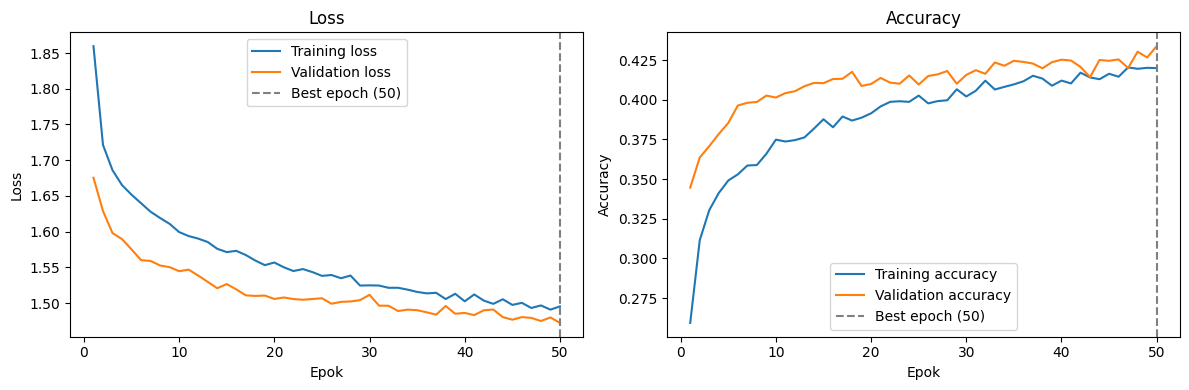

In [31]:
# step 1 - extract all images and labels from full training set
all_images = []
all_labels = []

for images, labels in full_train_ds:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print("Full dataset shape:", all_images.shape)
print("Class distribution:", np.unique(all_labels, return_counts=True))

# step 2 - split into train and val
X_train_full, X_val_full, y_train_full, y_val_full = train_test_split(
    all_images,
    all_labels,
    test_size=0.20,
    random_state=42,
    stratify=all_labels
)

print("X_train_full:", X_train_full.shape)
print("X_val_full:", X_val_full.shape)

# step 3 - make datasets
train_ds_full_transfer = make_dataset_transfer(X_train_full, y_train_full, shuffle=True)
val_ds_full_transfer   = make_dataset_transfer(X_val_full, y_val_full)

# step 4 - rebuild and retrain
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

transfer_model_full = build_transfer_model()

transfer_full_history = transfer_model_full.fit(
    train_ds_full_transfer,
    validation_data=val_ds_full_transfer,
    epochs=50,
    callbacks=[make_early_stopping(patience=5)]
)

plot_history(transfer_full_history)

Vi har nu nått bästa accuracy i hela projektet — 43 % valideringsaccuracy är en betydande förbättring jämfört med alla tidigare modeller, vilket bekräftar att mer data var den primära flaskhalsen hela tiden.
Modellens grafer visar jämna inlärningskurvor för både accuracy och loss som ökar/minskar smidigt och konsekvent över alla 50 epokerna utan instabilitet, kollaps eller plötsliga toppar. Gapet mellan validering och träningskurvorna visar inte på någon överanpassning vilket visar på att modellen generaliserar väl. 
Ett orosmoment är att kurvorna inte verkar ha planat ut vid epok 50, vilket innebär att modellen fortfarande kan behöva lära sig längre.

Graferna visar att en bättre uppdalning av train/validering från hela train datasetet gav en märkbar förbättring än tidigare körningar. Inför nästa finjustering kommer vi att öka epokerna för att ge modellen chansen att slutföra inlärningen. 


Epoch 1/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 139s 194ms/step - accuracy: 0.4205 - loss: 1.4928 - val_accuracy: 0.4310 - val_loss: 1.4725
Epoch 2/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 139s 193ms/step - accuracy: 0.4187 - loss: 1.4860 - val_accuracy: 0.4347 - val_loss: 1.4676
Epoch 3/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 139s 194ms/step - accuracy: 0.4251 - loss: 1.4823 - val_accuracy: 0.4317 - val_loss: 1.4709
Epoch 4/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 138s 192ms/step - accuracy: 0.4226 - loss: 1.4865 - val_accuracy: 0.4262 - val_loss: 1.4708
Epoch 5/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 138s 193ms/step - accuracy: 0.4260 - loss: 1.4850 - val_accuracy: 0.4269 - val_loss: 1.4755
Epoch 6/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 139s 194ms/step - accuracy: 0.4218 - loss: 1.4816 - val_accuracy: 0.4316 - val_loss: 1.4729
Epoch 7/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 138s 192ms/step - accuracy: 0.4232 - loss: 1.4807 - val_accuracy: 0.4284 - val_loss: 1.4747
Epoch 8/50
718/718 ━━━━━━━━━━━━━━━━━━━━ 138s 193ms/step - accuracy: 0.4247 -

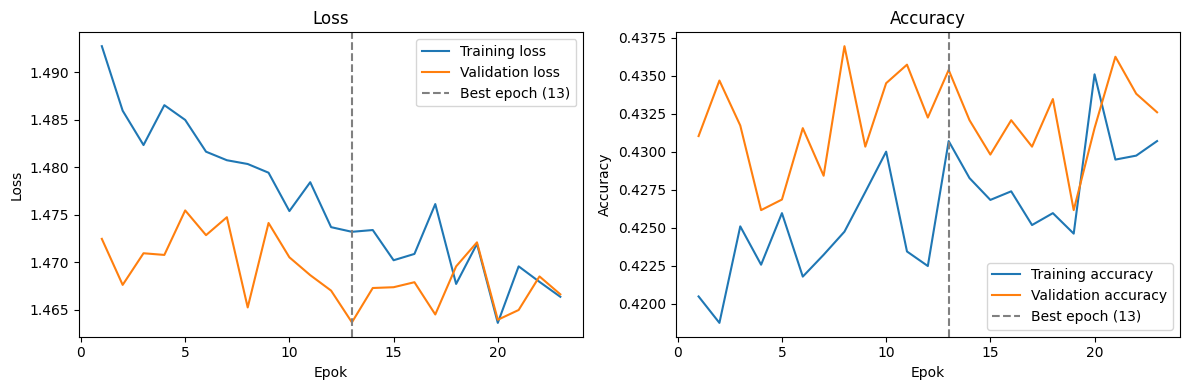

In [32]:
# continue training from where it stopped
continued_history = transfer_model_full.fit(
    train_ds_full_transfer,
    validation_data=val_ds_full_transfer,
    epochs=50,  # 50 more epochs
    callbacks=[make_early_stopping(patience=10)]
)

plot_history(continued_history)

Modellen har konvergerat – detta är det viktigaste fyndet. Loss rör sig knappt och svävar inom ett litet intervall på ~0,03 över 23 epoker innan tidigt stopp utlöstes. Träning och validering är i huvudsak identiska vid ~43 %. Det verkar inte finnas något mer kvar att extrahera med den nuvarande konfigurationen.

Kurvorna är mycket brusiga – både accuracy och loss hoppar avsevärt runt från epok till epok. 
Tidigt stopp utlöstes korrekt vid epok 23 – bäst var epok 13, tålamodet på 10 var uttömt, vikterna återställdes. 





### 7.3. Spara modellerna



In [38]:

baseline_model.save("../models/baseline_model.keras")
improved_model.save("../models/model_1.keras")
transfer_model_full.save("../models/transfer_model_full.keras")

## 7. Prediktioner på testdata

### 7.1. Ladd om testdatan

In [ ]:
# ladda om testdatan utan normalisering /255
test_ds_transfer = image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=32,
    label_mode="int",
    shuffle=False,
    color_mode="grayscale"
).map(lambda X, y: (tf.cast(X, tf.float32), y))\
 .prefetch(tf.data.AUTOTUNE)

# verifiera
for images, labels in test_ds_transfer.take(1):
    print("Shape:", images.shape)   # expect (32, 48, 48, 1)
    print("dtype:", images.dtype)   # expect float32
    print("min/max:", images.numpy().min(), images.numpy().max())  # expect 0.0 and ~255.0

Found 7178 files belonging to 7 classes.
Shape: (32, 48, 48, 1)
dtype: <dtype: 'float32'>
min/max: 0.0 255.0


### 7.2. Utvärdera på testdata

225/225 ━━━━━━━━━━━━━━━━━━━━ 20s 85ms/step
              precision    recall  f1-score   support

       angry       0.30      0.32      0.31       958
     disgust       0.00      0.00      0.00       111
        fear       0.33      0.23      0.27      1024
       happy       0.51      0.74      0.60      1774
     neutral       0.37      0.41      0.39      1233
         sad       0.40      0.21      0.28      1247
    surprise       0.59      0.62      0.61       831

    accuracy                           0.44      7178
   macro avg       0.36      0.36      0.35      7178
weighted avg       0.42      0.44      0.42      7178



c:\Users\Mauro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mauro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mauro\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

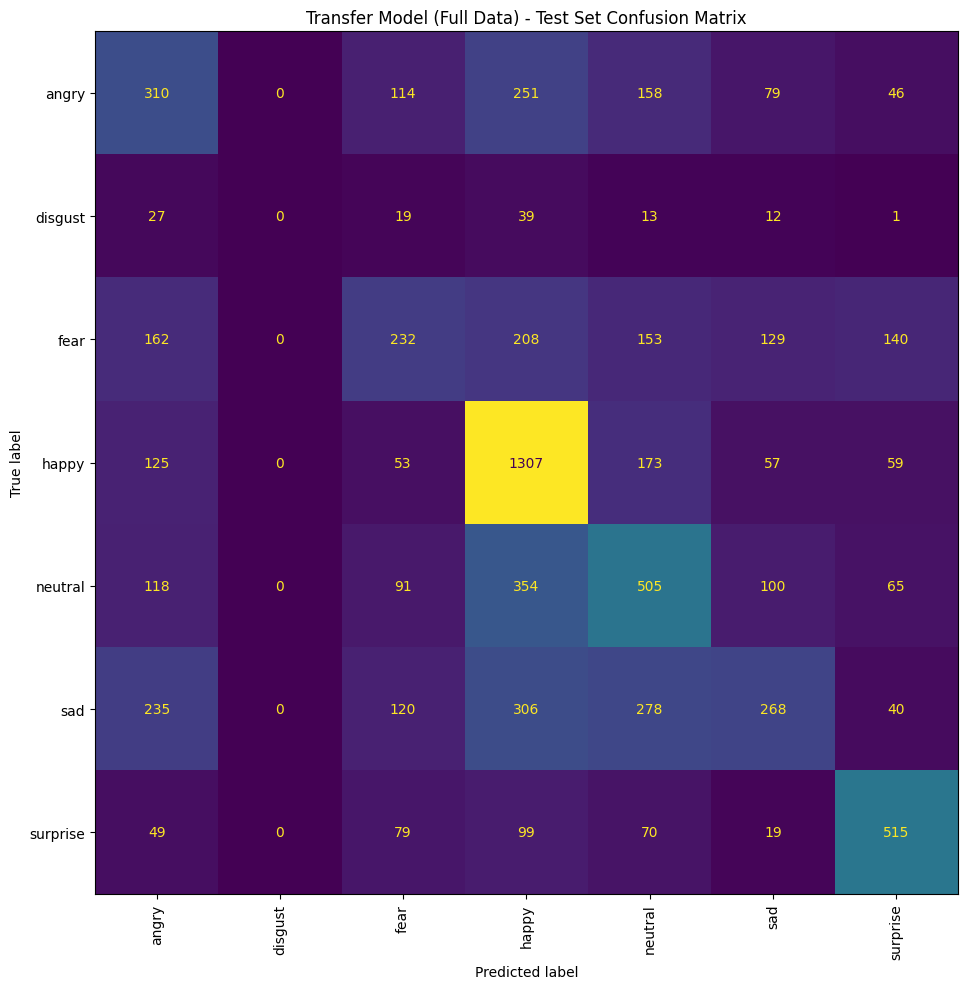

   class_id class_name  support  correct  accuracy
1         1    disgust      111        0  0.000000
5         5        sad     1247      268  0.214916
2         2       fear     1024      232  0.226562
0         0      angry      958      310  0.323591
4         4    neutral     1233      505  0.409570
6         6   surprise      831      515  0.619735
3         3      happy     1774     1307  0.736753


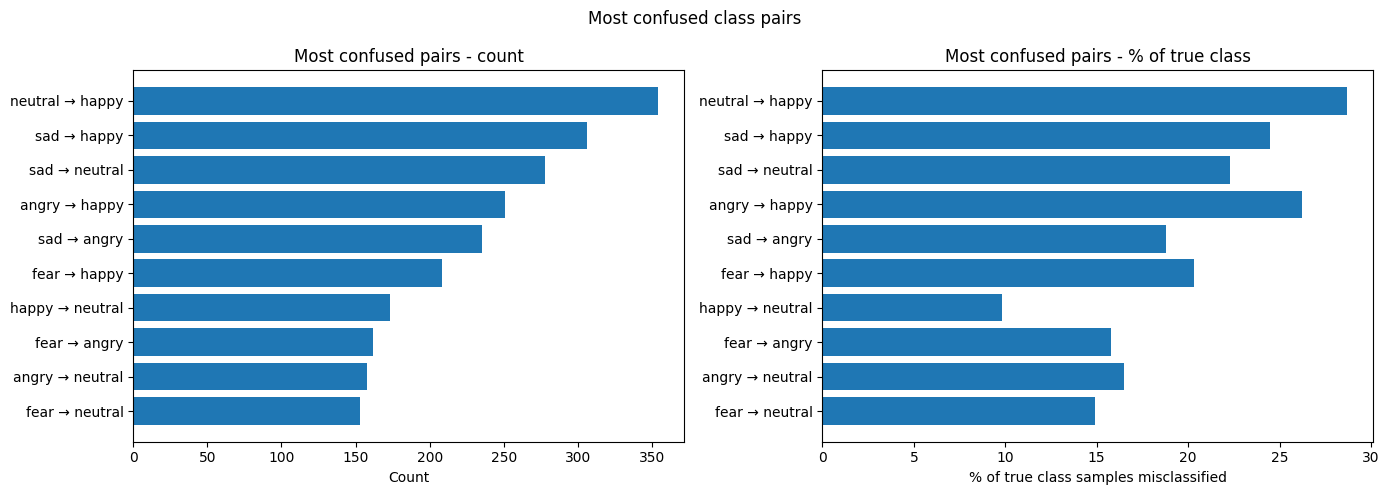

,true_class,predicted_class,count,pct_of_true_class
23,neutral,happy,354,28.7
28,sad,happy,306,24.5
29,sad,neutral,278,22.3
1,angry,happy,251,26.2
26,sad,angry,235,18.8
12,fear,happy,208,20.3
18,happy,neutral,173,9.8
11,fear,angry,162,15.8
2,angry,neutral,158,16.5
13,fear,neutral,153,14.9


In [35]:
X_test_full, y_test_full = extract_xy(test_ds_transfer)
y_pred_full = np.argmax(transfer_model_full.predict(X_test_full), axis=1)

print(classification_report(y_test_full, y_pred_full, target_names=class_names))

test_cm = plot_confusion_matrix(
    y_test_full, y_pred_full,
    class_names,
    title="Transfer Model (Full Data) - Test Set Confusion Matrix"
)

per_class = calculate_per_class_accuracy(test_cm, class_names)
print(per_class)

get_most_confused_pairs(test_cm, class_names)

44 % accuracy är det bästa resultatet i projektet  — ditt bästa resultat i hela projektet och överensstämmer med valideringsnoggrannheten på 43 %, vilket innebär att modellen generaliserar väl till ny data.

Starka klasser:

- Happy (1307)  — överlägset bäst. Leende är visuellt distinkt även vid 48×48
- Surprised (515) — höjda ögonbryn och öppen mun är igenkännbara drag
- Neutral(505) — överraskande med tanke på att det är ett subtilt uttryck

Svaga klasser:

- Disgust(0) — modellen förutsäger aldrig avsky korrekt vilket låter rimligt med tanke på klassobalansen. Avsky har bara 111 testbilder jämfört med 1 774 för glad. Modellen lärde sig att förutsägelse av avsky sällan belönas, så den slutade förutsäga det helt.
- Sad (268)— kraftigt förväxlad med glad och neutral
- Fear (232) — fördelad över flera klasser

Analys av förvirrade par

- Neutral → Happy (29 %) – modellen ser neutrala ansikten och tror att de ser glada ut. Vid 48×48 går den subtila skillnaden mellan ett neutralt uttryck och ett lätt leende förlorad.
- Angry → Happy (26 %) – överraskande men förklarlig. Modellen är partisk mot att förutsäga glad eftersom den dominerar träningsdata.
- Sad → Happy (25 %) – samma bias. Glad har 1 774 träningsprover som drar förutsägelser mot den.

Mönstret över nästan alla förvirrade par är att glad fungerar som en gravitationsbrunn – modellen är partisk mot att förutsäga den eftersom det var den vanligaste klassen i träning.

## 8. Analysera resultatet

### Slutliga resultat

| Model               |Train data    | Val Accuracy  | Status      |
|:--------            |:--------     |:--------      |:--------    |
| Basmodell CNN       | 2,240 subset |  ~38%         | Converged   |
| Improved CNN2       | 2,240 subset |  ~32%         | Converged   |
| Transfer (subset)   | 2,240 subset |  ~35%         | Converged   |
| Transfer (full data)|~23,000 images|  ~43%         | Bäst modell |
| Transfer (ny data)  | 7,178 images |  ~44%         | Bäst modell |

### Disgust flaskhalsen

Den största problematiken i projektet var utan tvekan *disgust* flaskhalsen, eftersom den klassen hade så väldigt få bilder att träna på. Detta bevisades även vid utvärderingen på testdatan där modellen  aldrig förutsäger *disgust* för någon bild. Detta är en direkt konsekvens av klassobalansen, *disgust* har bara 111 testbilder jämfört med 1 774 för glad. 

Anledningen att jag valde att ha kvar *disgust* fastän det ledde till så mycket problematik var i hoppet om att kunna hantera obalansen vid träningsdelen och därmed kunna bygga en modell som skulle kunna hantera alla klasser inklusive *disgust*. Utvärderingen visar dock att detta var feltänkt då det slutade med att modellen lärde sig att förutsägelse av *disgust* sällan belönas, så den slutade förutsäga det helt.

### Slutsatser

1. Datamängden är viktigast – att gå från 2 240 till 23 000 träningsbilder gav projektets största noggrannhetsökning, mer än någon arkitekturförändring.
2. Klassobalansen löstes aldrig helt – avskyklassen vid 0 % återkallelse är ett bevis på att varken den balanserade delmängden eller träning på fullständig data utan korrigering hanterade obalansen tillräckligt.
3. Modellen har lärt sig uttryckssvårigheter korrekt – den presterar bäst på visuellt distinkta uttryck (glad, förvånad) och sämst på subtila eller tvetydiga (neutral, rädsla, ledsen), vilket speglar mänsklig psykologisk forskning om ansiktsuttrycksigenkänning.
4. Transferinlärning var det rätta slutgiltiga valet – trots att den inte dramatiskt överträffade de anpassade CNN:erna vid validering, uppnådde den bästa testnoggrannheten och visade det mest stabila träningsbeteendet.


### Begränsningar

Rapporten visade några nackdelar i projektet: 

- Endast 2,240 träningsbilder efter balansering
- 48×48 gråskala är verkligen låg upplösning för subtila uttryck
- 7-klassig ansiktsuttrycksigenkänning är ett svårt problem även för toppmoderna modeller
- Flaskhalsen för *disgust* tvingade en delmängd att kassera 26 000 användbara bilder

### Möjliga förbättringar

Alternativa vägar för att förbättra modellen skulle kunna vara: 

- Finjustering av ofrysta lager (beprövade, instabila)
- Bilder med högre upplösning (96×96 eller 224×224)
- Mer varierad träningsdata eller förstärkning specifikt för minoritetsklasser
- En annan förtränad modell som är bättre lämpad för ansiktsuttryck

### Reflektion

Det var mycket nytt i projektet med flera nya utmaningar, ett av dem första var att förstå skillnaden mellan datasets och dataframe hantering, att förstå att jag enbart behöver X & y - delning för fall som scikit-learn modeller som random forest, logistic regression, etc. Att veta vilka funktioner som fungerar för ett dataset inom keras & tensorflow.

Klassobalansen och hur bäst man hanterar den. Jag trodde att om jag bara använde nog med olika metoder för att hantera obalansen som balanserat subset, data augmentation, etc. skulle jag kunna överkomma det men kom aldrig riktigt undan problematiken med att ha för få samples. 

Jag lärde mig att data-kvalitet är allt och det är svårt att träna en modell när träningsdatan är obalanserad. Om jag kunde börja om hade jag skippat *disgust*-klassen helt i både träning och test-setet.

Igenom projektet har jag gått igenom metodiken i detalj, använd flera olika metoder och jämfört och diskuterat hur dem har funkat och försökt bygga vidare på det och förbättrat därefter. Baserat på det tror jag att det här projektet är värt ett VG.